In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dm4bem

In [2]:
# Rooms geometry
l = 3               # m length of the cubic room
L = 5
w = 0.2
H = 3

# Window geometry
l_window = 1.25
L_window = 2
w_window = 0.07

# Doors geometry
l_door = 2.00
L_door = 0.90
w_door = 0.1

# Surfaces
S_window = l_window * L_window
S_door = l_door * L_door
S_wall_total = H * (2*L + 2*w + l)            # m² surface area of wall
S_wall_1 = S_wall_total - S_door
S_wall_2 = S_wall_total - S_door - S_window
S_wall_3 = l*H

# Temperatures

To_winter = 3     # degC
To_summer = 22    #degC
T1_sp_summer = 25  # degC
T1_sp_winter = 22  # degC
E_winter = 16     # W/m² tilted surface
E_summer = 41     # W/m² tilted surface

# Controller and time step
controller = False
imposed_time_step = False
Δt = 498    # s, imposed time step

In [3]:
air = {'Density': 1.2,                      # kg/m³
       'Specific heat': 1000}               # J/(kg·K)
pd.DataFrame(air, index=['Air'])

,Density,Specific heat
Air,1.2,1000


In [4]:
concrete = {'Conductivity': 1.740,          # W/(m·K)
            'Density': 2300.0,              # kg/m³
            'Specific heat': 880,           # J/(kg⋅K)
            'Width': w*0.8}                   # m

insulation = {'Conductivity': 0.035,        # W/(m·K)
              'Density': 55.0,              # kg/m³
              'Specific heat': 1210,        # J/(kg⋅K)
              'Width': w*0.2}                 # m

double_glass = {'Conductivity': 0.112,               # W/(m·K)
         'Density': 2500,                   # kg/m³
         'Specific heat': 1210,             # J/(kg⋅K)
         'Width': w_window,                 #m
         'Surface': S_window}               #m²

solid_wood = {'Conductivity': 0.14,               # W/(m·K)
         'Density': 2500,                   # kg/m³
         'Specific heat': 1210,             # J/(kg⋅K)
         'Width': w_door,                   # m
         'Surface': S_door}                 # m²

surfaces = {
    'Layer_out_1': S_wall_1,
    'Layer_in_1': S_wall_1,
    'Layer_out_2': S_wall_2,
    'Layer_in_2': S_wall_2,
    'Layer_out_3': S_wall_3,
    'Layer_in_3': S_wall_3,
}
 
wall = pd.DataFrame.from_dict({'Layer_out_1': concrete,
                               'Layer_in_1': insulation,
                               'Layer_out_2': concrete,
                               'Layer_in_2': insulation,
                               'Layer_out_3': concrete,
                               'Layer_in_3': insulation,
                               'Window': double_glass,
                               'Door': solid_wood},
                              orient='index')

wall['Surface'] = wall['Surface'].fillna(pd.Series(surfaces))

wall

,Conductivity,Density,Specific heat,Width,Surface
Layer_out_1,1.740,2300.0,880,0.16,38.4
Layer_in_1,0.035,55.0,1210,0.04,38.4
Layer_out_2,1.740,2300.0,880,0.16,35.9
Layer_in_2,0.035,55.0,1210,0.04,35.9
Layer_out_3,1.740,2300.0,880,0.16,9.0
Layer_in_3,0.035,55.0,1210,0.04,9.0
Window,0.112,2500.0,1210,0.07,2.5
Door,0.140,2500.0,1210,0.10,1.8


In [5]:
h = pd.DataFrame([{'in': 8., 'out': 25}], index=['h'])  # W/(m²⋅K)
h

,in,out
h,8.0,25


### Conduction conductances

$$G_{cd} = \frac{\lambda}{w}S$$

where:

- $\lambda$ - [thermal conductvity](https://en.m.wikipedia.org/wiki/Thermal_conductivity), W/(m⋅K);
- $w$ - width of the material, m;
- $S$ - surface area of the wall, m².

In [6]:
G_cd = wall['Conductivity'] / wall['Width'] * wall['Surface']
pd.DataFrame(G_cd, columns=['Conductance'])

,Conductance
Layer_out_1,417.6000
Layer_in_1,33.6000
Layer_out_2,390.4125
Layer_in_2,31.4125
Layer_out_3,97.8750
Layer_in_3,7.8750
Window,4.0000
Door,2.5200


### Convection conductances
$$G_{cv} = {h S}$$

where:
- $h$ is the [convection coefficient](https://en.m.wikipedia.org/wiki/Heat_transfer_coefficient), W/(m²⋅K);
- $S$ - surface area of the wall, m².

In [7]:
G_wall_1 = h * wall['Surface'].iloc[0]
G_wall_2 = h * wall['Surface'].iloc[2] 
G_wall_3 = h * wall['Surface'].iloc[4] 
G_window = h * wall['Surface'].iloc[6]     
G_door = h * wall['Surface'].iloc[7]

### Advection conductances

$$\dot{V}_a = \frac{\mathrm{ACH}}{3600} V_a$$

where:
- $\mathrm{ACH}$  ([air changes per hour](https://en.m.wikipedia.org/wiki/Air_changes_per_hour)) is the air infiltration rate, 1/h;
- $3600$ - number of seconds in one hour, s/h;
- $V_a$ - volume of the air in the thermal zone, m³.

Therefore, the conductance of [advection](https://en.m.wikipedia.org/wiki/Advection) by [ventilation](https://en.m.wikipedia.org/wiki/Ventilation_(architecture)) and/or [infiltration](https://en.m.wikipedia.org/wiki/Infiltration_(HVAC)), in W/K, is:

$$G_v = \rho_a c_a \dot{V}_a$$

In [8]:
Va = (L*l*H)                   # m³, volume of air
ACH = 1                     # 1/h, air changes per hour
Va_dot = ACH / 3600 * Va    # m³/s, air infiltration

Gv = air['Density'] * air['Specific heat'] * Va_dot

### Proportional controller

$$ q_{HVAC} = K_p (T_{i, sp} - \theta_i)$$

where:
- $K_p$ is the proportional gain of the controller, W/K;
- $T_{i, sp}$ - indoor temperature [setpoint](https://en.m.wikipedia.org/wiki/Setpoint_(control_system)), °C (noted in majuscule because it is an *input*, i.e., independent, variable);
- $\theta_i$ - indoor temperature, °C (noted in minuscule because it is an *output*, i.e., dependent variable).

In [9]:
# P-controler gain
# Kp = 1e4            # almost perfect controller Kp -> ∞
# Kp = 1e-3           # no controller Kp -> 0
if controller:
    Kp = 1e4
else:
    Kp = 1e-3

### Conductances in series and/or parallel

$$ G_{gs} = \frac{1}{1/G_{g,cv.out } + 1/(2 G_{g,cd})} =  
\frac{1}{\frac{1}{h_{out} S_g} + \frac{w / 2}{\lambda S_g}}
$$

In [10]:
Ggs_window = float(1 / (1 / G_window.loc['h', 'out'] + 1 / (2 * G_cd['Window'])))
Ggs_door = float(1 / (1 / G_window.loc['h', 'out'] + 1 / (2 * G_cd['Door'])))

Ggs_1 = Ggs_door
Ggs_2 = Ggs_door + Ggs_window

#### Thermal capacities

$$C_w= m_w c_w= \rho_w c_w w_w S_w$$

where:
- $m_w = \rho_w w_w S_w$ is the mass of the wall, kg;
- $c_w$ - [specific heat capacity](https://en.m.wikipedia.org/wiki/Specific_heat_capacity), J/(kg⋅K);
- $\rho_w$ - [density](https://en.m.wikipedia.org/wiki/Density), kg/m³;
- $w_w$ - width of the wall, m;
- $S_w$ - surface area of the wall, m².

In [11]:
C = wall['Density'] * wall['Specific heat'] * wall['Surface'] * wall['Width']
pd.DataFrame(C, columns=['Capacity'])

C['Air'] = air['Density'] * air['Specific heat'] * Va
pd.DataFrame(C, columns=['Capacity'])

,Capacity
Layer_out_1,12435456.0
Layer_in_1,102220.8
Layer_out_2,11625856.0
Layer_in_2,95565.8
Layer_out_3,2914560.0
Layer_in_3,23958.0
Window,529375.0
Door,544500.0
Air,54000.0


#### Thermal circuit

In [12]:
# temperature nodes
nθ = 8      # number of temperature nodes
θ = [f'θ{i}' for i in range(nθ)]
print(θ)

# flow-rate branches
nq = 13     # number of flow branches
q = [f'q{i}' for i in range(nq)]
print(q)

['θ0', 'θ1', 'θ2', 'θ3', 'θ4', 'θ5', 'θ6', 'θ7']
['q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12']


In [13]:
neglect_air_glass = False

if neglect_air_glass:
    C = np.array([0, 0, C['Layer_out_1'], C['Layer_in_1'], C['Layer_out_3'], C['Layer_in_3'],
                  C['Layer_out_2'], C['Layer_in_2']])
else:
    C = np.array([C['Air'], C['Air'], C['Layer_out_1'], C['Layer_in_1'], C['Layer_out_3'], C['Layer_in_3'],
                  C['Layer_out_2'], C['Layer_in_2']])

pd.DataFrame(C, index=θ)

,0
θ0,54000.0
θ1,54000.0
θ2,12435456.0
θ3,102220.8
θ4,2914560.0
θ5,23958.0
θ6,11625856.0
θ7,95565.8


#### A: incidence matrix

In [14]:
A = np.zeros([nq, nθ])       # n° of branches X n° of nodes

A[0, 2] = 1
A[1, 7] = 1
A[2, 0] = 1
A[3, 1] = 1
A[4, 0], A[4, 3] = -1, 1
A[5, 0], A[5, 4] = -1, 1
A[6, 5], A[6, 1] = -1, 1
A[7, 1], A[7, 6] = -1, 1
A[8, 2], A[8, 3] = -1, 1
A[9, 4], A[9, 5] = -1, 1
A[10, 7], A[10, 6] = -1, 1
A[11, 1] = 1
A[12, 0] = 1

pd.DataFrame(A, index=q, columns=θ)

,θ0,θ1,θ2,θ3,θ4,θ5,θ6,θ7
q0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
q1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
q2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
q3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
q4,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
q5,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
q6,0.0,1.0,0.0,0.0,0.0,-1.0,0.0,0.0
q7,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0
q8,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0
q9,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0


#### G: conductance matrix

In [15]:
G = np.array(np.hstack(
    [G_wall_1['out'],
     G_wall_2['out'],
     Ggs_1, #G_door['out'],
     Ggs_2, #G_door['out'] + G_window['out'],
     G_wall_1['in'],
     G_wall_3['in'],
     G_wall_3['in'],
     G_wall_2['in'],
     G_cd['Layer_in_1'] + G_cd['Layer_out_1'],
     G_cd['Layer_in_3'] + G_cd['Layer_out_3'],
     G_cd['Layer_in_2'] + G_cd['Layer_out_2'],
     Gv,
     Kp]))

pd.DataFrame(G, index=q)

,0
q0,960.000000
q1,897.500000
q2,4.663903
q3,11.756101
q4,307.200000
q5,72.000000
q6,72.000000
q7,287.200000
q8,451.200000
q9,105.750000


#### b: temperature source vector

In [16]:
b = pd.Series(['To', 'To', 'To', 'To', 0, 0, 0, 0, 0, 0, 0, 'To', 'Ti_sp'],
              index=q)

pd.DataFrame(b, index=q)

,0
q0,To
q1,To
q2,To
q3,To
q4,0
q5,0
q6,0
q7,0
q8,0
q9,0


#### f: heat flow source vector

In [17]:
f = pd.Series([0, 0,'Φo', 'Φo', 'Φi', 'Φi', 'Φo', 'Φo'],
              index=θ)
pd.DataFrame(f, index=θ)

,0
θ0,0
θ1,0
θ2,Φo
θ3,Φo
θ4,Φi
θ5,Φi
θ6,Φo
θ7,Φo


In [18]:
y = np.zeros(nθ)         # nodes
y[[0]] = y[[1]] = 1              # nodes (temperatures) of interest
pd.DataFrame(y, index=θ)

,0
θ0,1.0
θ1,1.0
θ2,0.0
θ3,0.0
θ4,0.0
θ5,0.0
θ6,0.0
θ7,0.0


In [19]:
# thermal circuit
A = pd.DataFrame(A, index=q, columns=θ)
G = pd.Series(G, index=q)
C = pd.Series(C, index=θ)
b = pd.Series(b, index=q)
f = pd.Series(f, index=θ)
y = pd.Series(y, index=θ)

TC = {"A": A,
      "G": G,
      "C": C,
      "b": b,
      "f": f,
      "y": y}

### Steady-state estimation

In [20]:
print(b)

q0        To
q1        To
q2        To
q3        To
q4         0
q5         0
q6         0
q7         0
q8         0
q9         0
q10        0
q11       To
q12    Ti_sp
dtype: object


In [21]:
α = 0.5
Φo_summer = α * E_summer * S_wall_total
Φo_winter = α * E_winter * S_wall_total
Φi_summer = α * E_summer * S_wall_3
Φi_winter = α * E_winter * S_wall_3

b_summer = (
    b
    .replace({'To': To_summer, 'Ti_sp': T1_sp_summer})
    .to_numpy(dtype=float)
    .flatten()
)

b_winter = (
    b
    .replace({'To': To_winter, 'Ti_sp': T1_sp_winter})
    .to_numpy(dtype=float)
    .flatten()
)

f_summer = (
    f
    .replace({'Φo': Φo_summer, 'Φi': Φi_summer})
    .to_numpy(dtype=float)
    .flatten()
)

f_winter = (
    f
    .replace({"Φo": Φo_winter, "Φi": Φi_winter})
    .to_numpy(dtype=float)
    .flatten()
)

G = TC['G']
diag_G = pd.DataFrame(np.diag(G), index=G.index, columns=G.index)

θss_summer = np.linalg.inv(TC['A'].T @ diag_G @ TC['A']) @ (TC['A'].T @ diag_G @ b_summer + f_summer)
qss_summer = np.diag(G) @ (-TC['A'] @ θss_summer + b_summer)
print("Summer: Room 1 controlled, Room 2 in free running")
print("θ:", np.around(θss_summer[0:2],2), "°C")
print("q:", np.around(qss_summer[12],2), "W")

θss_winter = np.linalg.inv(TC['A'].T @ diag_G @ TC['A']) @ (TC['A'].T @ diag_G @ b_winter + f_winter)
qss_winter = np.diag(G) @ (-TC['A'] @ θss_winter + b_winter)
print("Winter: Room 1 controlled, Room 2 in free running")
print("θ:", np.around(θss_winter[0:2],2), "°C")
print("q:", np.around(qss_winter[12],2), "W")

Summer: Room 1 controlled, Room 2 in free running
θ: [26.56 26.32] °C
q: -0.0 W
Winter: Room 1 controlled, Room 2 in free running
θ: [4.78 4.68] °C
q: 0.02 W


### State-space representation

$$C \dot{\theta} = -(A^T G A) \theta + A^T G b + f$$

is transformed in [state-space representation](https://en.m.wikipedia.org/wiki/State-space_representation) ([Ghiaus 2013](https://hal.archives-ouvertes.fr/hal-03605823/document)):

$$\left\{\begin{array}{rr}
\dot{\theta}_s=A_s \theta_s + B_s u\\ 
y = C_s \theta_s + D_s u
\end{array}\right.$$

where:
- $\theta_s$ is the vector of state variables which are the temperatures of nodes containing capacities. Its elements are in the same order as in the vector of temperatures, $\theta$; its dimension, $\dim \theta_s$, is equal to the number of capacities from the thermal network.

- $u = \begin{bmatrix} b_T \\ f_Q\end{bmatrix}$ - vector of inputs of dimension $\dim u$ equal to the number of sources (of temperaure, $b_T$, and heat flows, $f_Q$) of the thermal network, where:

    - vector $b_T$ of nonzero elements of vector $b$ of temperature sources. 
    - vector $f_Q$ of nonzero elements of vector $f$ of flow sources.
    
- $y$ - vector of outputs, a subset of vector $\theta$ representing temperature nodes which are of interest.

- $A_s$ - state matrix, of dimension $\dim A_s = \dim {\theta_s} \times \dim {\theta_s}$.

- $B_s$ - input matrix, of dimension $\dim B_s = \dim {\theta_s} \times \dim u$.

- $C_s$ - output matrix, of dimension $\dim C_s = \dim y \times \dim {\theta_s}$.

- $D_s$ - feedthrough (or feedforward) matrix, of dimension $\dim D_s = \dim y \times \dim u$.

- $u_s$ - correspondence  between _inputs_ (branches with temperature sources and nodes with flow-rate sources) and  _input data set_ (names of temperature and  flow rate sources).

In [22]:
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

us_summer = (
    us
    .replace({'To': To_summer, 'Ti_sp': T1_sp_summer, 'Φo': Φo_summer, 'Φi': Φi_summer})
    .to_numpy(dtype=float)
    .flatten()
)

us_winter = (
    us
    .replace({'To': To_winter, 'Ti_sp': T1_sp_winter, 'Φo': Φo_winter, 'Φi': Φi_winter})
    .to_numpy(dtype=float)
    .flatten()
)

In [23]:
inv_As = pd.DataFrame(np.linalg.inv(As),
                      columns=As.index, index=As.index)
yss_summer = (-Cs @ inv_As @ Bs + Ds) @ us_summer

yss_summer_1 = float(yss_summer.values[0])
yss_summer_2 = float(yss_summer.values[1])
print(f'yss_summer room 1 = {yss_summer_1:.2f} °C')
print(f'yss_summer room 2 = {yss_summer_2:.2f} °C')

yss_winter = (-Cs @ inv_As @ Bs + Ds) @ us_winter

yss_winter_1 = float(yss_winter.values[0])
yss_winter_2 = float(yss_winter.values[1])
print(f'yss_winter room 1 = {yss_winter_1:.2f} °C')
print(f'yss_winter room 2 = {yss_winter_2:.2f} °C')

yss_summer room 1 = 26.56 °C
yss_summer room 2 = 26.32 °C
yss_winter room 1 = 4.78 °C
yss_winter room 2 = 4.68 °C


The error between the steady-state values obtained from the system of DAE, $\theta_0$, and the output of the state-space representation, $y_{ss}$, 

$$\varepsilon = \left | \theta_0 - y_{ss} \right |$$

is practically zero; the slight difference is due to [numerical errors](https://en.m.wikipedia.org/wiki/Numerical_error).

In [24]:
print(f'Error between DAE and state-space in summer: {abs(θss_summer[0] - yss_summer_1):.2e} °C')
print(f'Error between DAE and state-space in winter: {abs(θss_winter[0] - yss_winter_1):.2e} °C')

print(f'Error between DAE and state-space in summer: {abs(θss_summer[1] - yss_summer_2):.2e} °C')
print(f'Error between DAE and state-space in winter: {abs(θss_winter[1] - yss_winter_2):.2e} °C')

Error between DAE and state-space in summer: 3.55e-15 °C
Error between DAE and state-space in winter: 8.88e-16 °C
Error between DAE and state-space in summer: 1.07e-14 °C
Error between DAE and state-space in winter: 1.78e-15 °C


### Eigenvalues analysis

Let's consider the eigenvalues $\lambda$ of the state matrix $A_s$.

In [25]:
# Eigenvalues analysis
λ = np.linalg.eig(As)[0]        # eigenvalues of matrix As

print(λ)

[-1.14104006e-02 -1.38170703e-02 -9.30549212e-03 -3.15690732e-03
 -5.30449983e-03 -8.23032885e-05 -2.34376283e-05 -3.51660502e-05]


In [26]:
# time step
Δtmax = 2 * min(-1. / λ)    # max time step for stability of Euler explicit
dm4bem.print_rounded_time('Δtmax', Δtmax)

if imposed_time_step:
    dt = Δt
else:
    dt = dm4bem.round_time(Δtmax)

dm4bem.print_rounded_time('dt', dt)

if dt < 10:
    raise ValueError("Time step is too small. Stopping the script.")

Δtmax = 144 s = 2.4 min
dt = 120 s = 2.0 min


In [27]:
# settling time
t_settle = 4 * max(-1 / λ)
dm4bem.print_rounded_time('t_settle', t_settle)

t_settle = 170665 s = 47.4 h


In [28]:
# duration: next multiple of 3600 s that is larger than t_settle
duration = np.ceil(t_settle / 3600) * 3600
dm4bem.print_rounded_time('duration', duration)

duration = 172800 s = 48.0 h


In [29]:
# Create input_data_set
# ---------------------
# time vector
n = int(np.floor(duration / dt))    # number of time steps

# DateTimeIndex starting at "00:00:00" with a time step of dt
time = pd.date_range(start="2000-01-01 00:00:00",
                           periods=n, freq=f"{int(dt)}s")

To = To_summer * np.ones(n)        # outdoor temperature
Ti_sp = T1_sp_summer * np.ones(n)     # indoor temperature set point
Qa = Φa = Φo_summer * np.ones(n)         # # auxiliary heat sources and solar radiation


data_summer = {'To': To_summer * np.ones(n), 'Ti_sp': T1_sp_summer * np.ones(n), 'Φo': Φo_summer * np.ones(n), 'Φi': Φi_summer * np.ones(n), 'Qa': Qa, 'Φa': Φa}
input_data_set_summer = pd.DataFrame(data_summer, index=time)
# inputs in time from input_data_set
u_summer = dm4bem.inputs_in_time(us, input_data_set_summer)

data_winter = {'To': To_winter * np.ones(n), 'Ti_sp': T1_sp_winter * np.ones(n), 'Φo': Φo_winter * np.ones(n), 'Φi': Φi_winter * np.ones(n), 'Qa': Qa, 'Φa': Φa}
input_data_set_winter = pd.DataFrame(data_winter, index=time)
# inputs in time from input_data_set
u_winter = dm4bem.inputs_in_time(us, input_data_set_winter)

In [30]:
# Initial conditions
θ_exp = pd.DataFrame(index=u_summer.index)     # empty df with index for explicit Euler
θ_imp = pd.DataFrame(index=u_summer.index)     # empty df with index for implicit Euler

θ0 = 0.0                    # initial temperatures
θ_exp[As.columns] = θ0      # fill θ for Euler explicit with initial values θ0
θ_imp[As.columns] = θ0      # fill θ for Euler implicit with initial values θ0

I = np.eye(As.shape[0])     # identity matrix
for k in range(u_summer.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u_summer.iloc[k]
    θ_imp.iloc[k + 1] = np.linalg.inv(I - dt * As)\
        @ (θ_imp.iloc[k] + dt * Bs @ u_summer.iloc[k])
    
# outputs
y_exp_summer = (Cs @ θ_exp.T + Ds @  u_summer.T).T
y_imp_summer = (Cs @ θ_imp.T + Ds @  u_summer.T).T

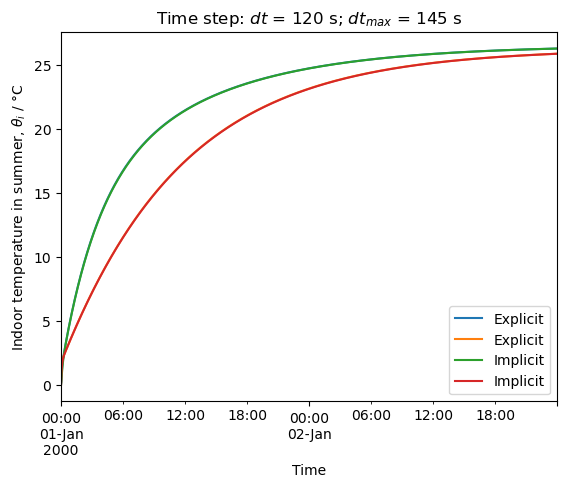

Steady-state indoor temperature for room 1 obtained with:
- DAE model: 26.5633 °C
- state-space model: 26.5633 °C
- steady-state response to step input: 26.3178 °C
Steady-state indoor temperature for room 2 obtained with:
- DAE model: 26.3169 °C
- state-space model: 26.3169 °C
- steady-state response to step input: 25.9121 °C


In [31]:
# plot results
y = pd.concat([y_exp_summer, y_imp_summer], axis=1, keys=['Explicit', 'Implicit'])
# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature in summer, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()

print('Steady-state indoor temperature for room 1 obtained with:')
print(f'- DAE model: {float(θss_summer[0]):.4f} °C')
print(f'- state-space model: {float(yss_summer_1):.4f} °C')
print(f'- steady-state response to step input: \
{y_exp_summer["θ0"].tail(1).values[0]:.4f} °C')

print('Steady-state indoor temperature for room 2 obtained with:')
print(f'- DAE model: {float(θss_summer[1]):.4f} °C')
print(f'- state-space model: {float(yss_summer_2):.4f} °C')
print(f'- steady-state response to step input: \
{y_exp_summer["θ1"].tail(1).values[0]:.4f} °C')

In [32]:
# Initial conditions
θ_exp = pd.DataFrame(index=u_winter.index)     # empty df with index for explicit Euler
θ_imp = pd.DataFrame(index=u_winter.index)     # empty df with index for implicit Euler

θ0 = 0.0                    # initial temperatures
θ_exp[As.columns] = θ0      # fill θ for Euler explicit with initial values θ0
θ_imp[As.columns] = θ0      # fill θ for Euler implicit with initial values θ0

I = np.eye(As.shape[0])     # identity matrix
for k in range(u_winter.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u_winter.iloc[k]
    θ_imp.iloc[k + 1] = np.linalg.inv(I - dt * As)\
        @ (θ_imp.iloc[k] + dt * Bs @ u_winter.iloc[k])
    
# outputs
y_exp_winter = (Cs @ θ_exp.T + Ds @  u_winter.T).T
y_imp_winter = (Cs @ θ_imp.T + Ds @  u_winter.T).T

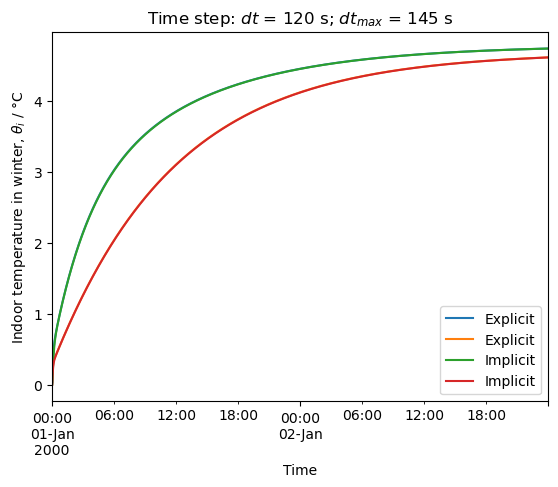

Steady-state indoor temperature for room 1 obtained with:
- DAE model: 4.7809 °C
- state-space model: 4.7809 °C
- steady-state response to step input: 4.7361 °C
Steady-state indoor temperature for room 2 obtained with:
- DAE model: 4.6846 °C
- state-space model: 4.6846 °C
- steady-state response to step input: 4.6114 °C


In [33]:
# plot results
y = pd.concat([y_exp_winter, y_imp_winter], axis=1, keys=['Explicit', 'Implicit'])
# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature in winter, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()

print('Steady-state indoor temperature for room 1 obtained with:')
print(f'- DAE model: {float(θss_winter[0]):.4f} °C')
print(f'- state-space model: {float(yss_winter_1):.4f} °C')
print(f'- steady-state response to step input: \
{y_exp_winter["θ0"].tail(1).values[0]:.4f} °C')

print('Steady-state indoor temperature for room 2 obtained with:')
print(f'- DAE model: {float(θss_winter[1]):.4f} °C')
print(f'- state-space model: {float(yss_winter_2):.4f} °C')
print(f'- steady-state response to step input: \
{y_exp_winter["θ1"].tail(1).values[0]:.4f} °C')

In [34]:
results_table = pd.DataFrame({
    "Method": ["DAE", "State Space", "Step Input"],
    "Room 1 Summer θ [°C]": [
        θss_summer[0],
        yss_summer_1,
        y_exp_summer['θ0'].tail(1).values[0]
    ],
    "Room 2 Summer θ [°C]": [
        θss_summer[1],
        yss_summer_2,
        y_exp_summer['θ1'].tail(1).values[0]
    ],
    "Room 1 Winter θ [°C]": [
        θss_winter[0],
        yss_winter_1,
        y_exp_winter['θ0'].tail(1).values[0]
    ],
    "Room 2 Winter θ [°C]": [
        θss_winter[1],
        yss_winter_2,
        y_exp_winter['θ1'].tail(1).values[0]
    ]
})

display(results_table.round(2))

,Method,Room 1 Summer θ [°C],Room 2 Summer θ [°C],Room 1 Winter θ [°C],Room 2 Winter θ [°C]
0,DAE,26.56,26.32,4.78,4.68
1,State Space,26.56,26.32,4.78,4.68
2,Step Input,26.32,25.91,4.74,4.61
